In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import seaborn as sns

In [6]:
import matplotlib.pyplot as plt

In [7]:
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"

In [8]:
df = pd.read_csv(url)
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,31/12/19,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,01/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,02/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,03/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,04/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


# 2. High level data understanding

In [10]:
# a. Number rows and columns in the dataset
df.shape

(57394, 49)

In [11]:
#b. Datatypes of columns
df.dtypes

iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekly_icu_admissions             

In [12]:
#c. Info  & describe of data in Dataframe
df.info

<bound method DataFrame.info of       iso_code continent       location      date  total_cases  new_cases  \
0          AFG      Asia    Afghanistan  31/12/19          NaN        0.0   
1          AFG      Asia    Afghanistan  01/01/20          NaN        0.0   
2          AFG      Asia    Afghanistan  02/01/20          NaN        0.0   
3          AFG      Asia    Afghanistan  03/01/20          NaN        0.0   
4          AFG      Asia    Afghanistan  04/01/20          NaN        0.0   
...        ...       ...            ...       ...          ...        ...   
57389      NaN       NaN  International  13/11/20        696.0        NaN   
57390      NaN       NaN  International  14/11/20        696.0        NaN   
57391      NaN       NaN  International  15/11/20        696.0        NaN   
57392      NaN       NaN  International  16/11/20        696.0        NaN   
57393      NaN       NaN  International  17/11/20        696.0        NaN   

       new_cases_smoothed  total_deaths  ne

In [13]:
df.describe

<bound method NDFrame.describe of       iso_code continent       location      date  total_cases  new_cases  \
0          AFG      Asia    Afghanistan  31/12/19          NaN        0.0   
1          AFG      Asia    Afghanistan  01/01/20          NaN        0.0   
2          AFG      Asia    Afghanistan  02/01/20          NaN        0.0   
3          AFG      Asia    Afghanistan  03/01/20          NaN        0.0   
4          AFG      Asia    Afghanistan  04/01/20          NaN        0.0   
...        ...       ...            ...       ...          ...        ...   
57389      NaN       NaN  International  13/11/20        696.0        NaN   
57390      NaN       NaN  International  14/11/20        696.0        NaN   
57391      NaN       NaN  International  15/11/20        696.0        NaN   
57392      NaN       NaN  International  16/11/20        696.0        NaN   
57393      NaN       NaN  International  17/11/20        696.0        NaN   

       new_cases_smoothed  total_deaths  

# 3. Low level data understanding

In [14]:
# a. count of unique values in location column
df['location'].nunique()

216

In [15]:
# b. which continent has maximum frequency using values counts
df['continent'].value_counts()

continent
Europe           14828
Africa           13637
Asia             13528
North America     9116
South America     3404
Oceania           2235
Name: count, dtype: int64

In [16]:
#c. maximum & mean value in total_cases
df['total_cases'].max()

55154651.0

In [17]:
df['total_cases'].mean()

np.float64(167797.3688753302)

In [18]:
# d.25%,50% & 75% quartile value in 'total_deaths'
df['total_deaths'].quantile([0.25,0.5,0.75])

0.25     13.0
0.50     84.0
0.75    727.0
Name: total_deaths, dtype: float64

In [19]:
# e. which continent has maximum human_development_index
df.groupby('continent')['human_development_index'].max()

continent
Africa           0.797
Asia             0.933
Europe           0.953
North America    0.926
Oceania          0.939
South America    0.843
Name: human_development_index, dtype: float64

In [20]:
# f. which continent has minimum 'gdp_per_capita'
df.groupby('continent')['gdp_per_capita'].min()

continent
Africa            661.240
Asia             1479.147
Europe           5189.972
North America    1653.173
Oceania          2205.923
South America    6885.829
Name: gdp_per_capita, dtype: float64

# 4.Filter the dataframe with only this columns
['continent','location','date','total_cases','total_deaths','gdp_per_ca
pita','
human_development_index'] and update the data frame.

In [21]:
df = df[['continent','location','date','total_cases','total_deaths',
         'gdp_per_capita','human_development_index']]

df.head()

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498


# 5. Data Cleaning

In [22]:
# a. Remove all duplicates observations
df = df.drop_duplicates()

In [23]:
# b. missing values in all columns
df.isnull().sum()

continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64

In [24]:
# c. Remove all observations where continent column value is missing
df = df.dropna(subset=['continent'])

In [25]:
# d.Fill all missing values with 0
df = df.fillna(0)

# 6.Date Time Format

In [26]:
# a. Convert date column in datetime format using pandas.to_datetime
df['date'] = pd.to_datetime(df['date'])

C:\Users\ANSILA\AppData\Local\Temp\ipykernel_9608\1812137655.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [27]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [28]:
# b. Create new column month after extracting month data from date column.
df['month'] = df['date'].dt.month

# 7.Data Aggregation

In [29]:
# a. Find max value in all columns using groupby function on 'continent' column
# b. Store the result in a new dataframe named 'df_groupby'.
df_groupby = df.groupby('continent').max().reset_index()
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12
1,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12
2,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12
3,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12
4,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12
5,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12


# 8.Feature Engineering

In [30]:
# a. Create a new feature 'total_deaths_to_total_cases' by ratio of 'total_deaths' column to 'total_cases'
df_groupby['total_deaths_to_total_cases'] = \
df_groupby['total_deaths'] / df_groupby['total_cases']
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month,total_deaths_to_total_cases
0,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12,0.027004
1,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12,0.014708
2,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12,0.026188
3,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12,0.022062
4,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12,0.032685
5,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12,0.028251


# 9.Data Visualization

C:\Users\ANSILA\AppData\Local\Temp\ipykernel_9608\4076826368.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['gdp_per_capita'])


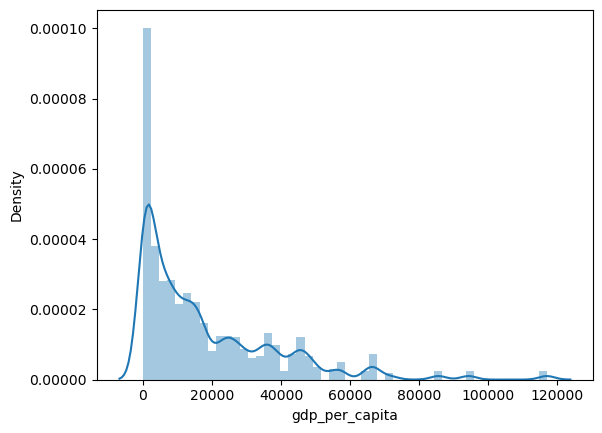

In [31]:
# a. Perform Univariate analysis on 'gdp_per_capita' column by plotting histogram using seaborn dist plot.
sns.distplot(df['gdp_per_capita'])
plt.show()

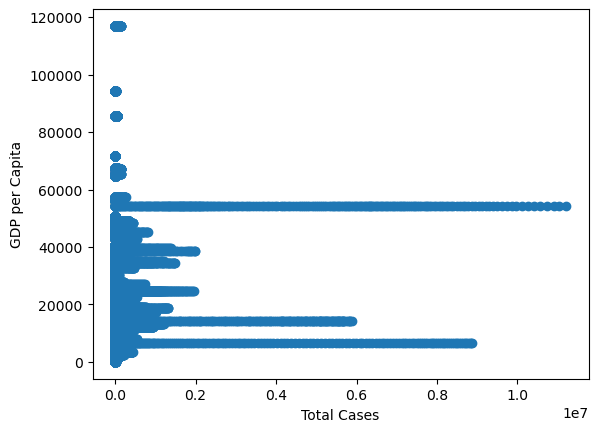

In [34]:
# b. Plot a scatter plot of 'total_cases' & 'gdp_per_capita'
plt.scatter(df['total_cases'], df['gdp_per_capita'])
plt.xlabel("Total Cases")
plt.ylabel("GDP per Capita")
plt.show()

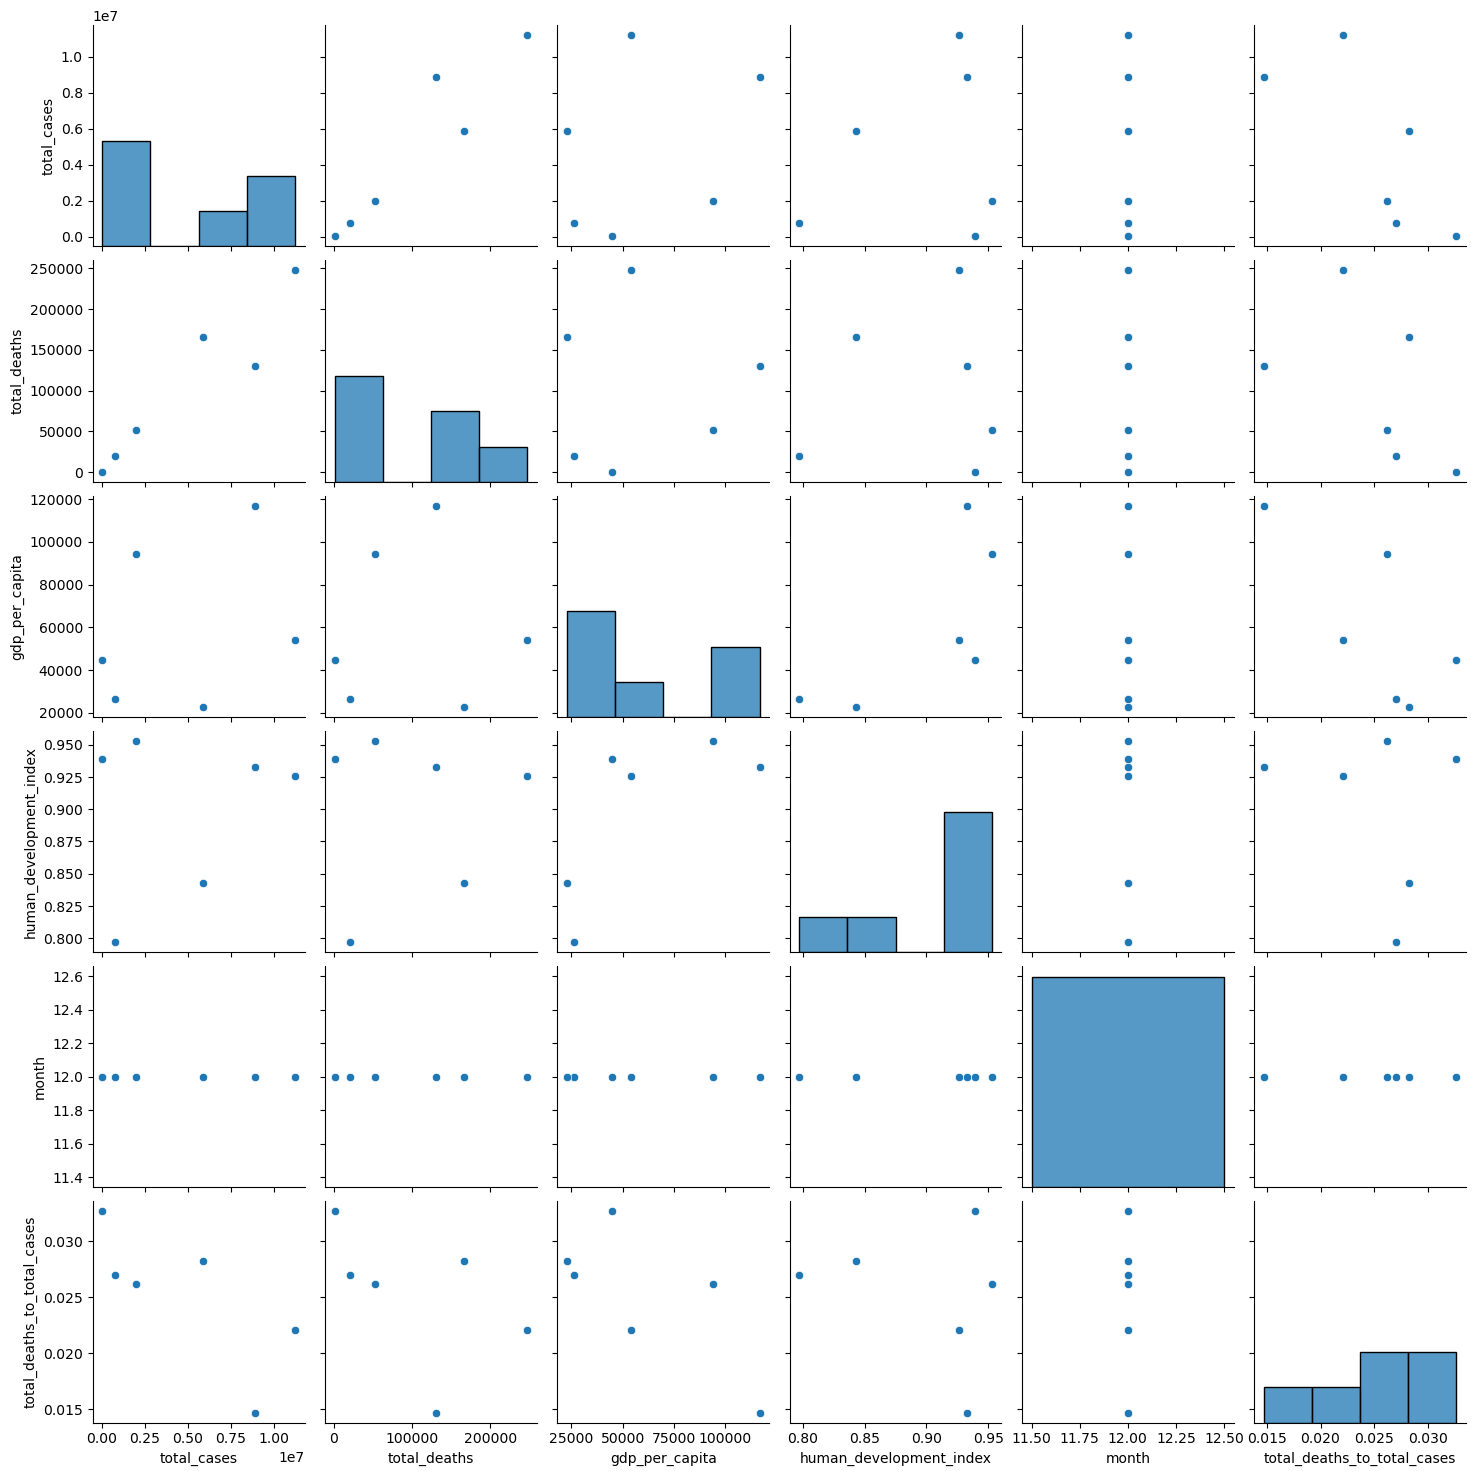

In [35]:
# c. Plot Pairplot on df_groupby dataset.
sns.pairplot(df_groupby)
plt.show()

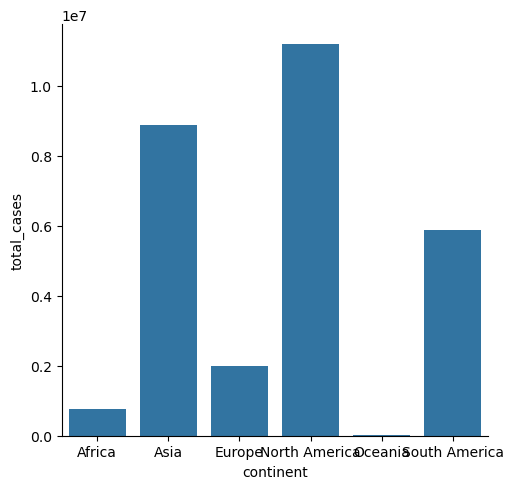

In [36]:
# d. Plot a bar plot of 'continent' column with 'total_cases' 
sns.catplot(data=df_groupby,
            x='continent',
            y='total_cases',
            kind='bar')
plt.show()

# 10.Save the df_groupby dataframe in your local drive using pandas.to_csv function .

In [37]:
df_groupby.to_csv("covid_groupby_analysis.csv", index=False)